## Mulliken population analysis

Assigns Mulliken charges on atoms given density matrix and corresponding overlap matrix.

Include the keyword `GFInput` in the Gaussian input file's route section to print the basis set information, or provide the `.fchk` and `.log` files.

In [1]:
import numpy as np
import scipy as sp
import sys
import matplotlib.pyplot as plt
sys.path.append('/mnt/d/Github/kranka_ucm/scripts/')
sys.path.append('/mnt/c/Users/kranka/Github/kranka_ucm/scripts/')
from gauss_hf import *

In [2]:
#====================
# CONVERSION FACTORS
#====================
# length: 1 bohr = 0.529177210903 angstroms
A0toANG = 0.529177
ANGtoA0 = 1/A0toANG

Build a `class` object for the set of basis functions

In [3]:
class basis:
    def __init__(self, pathLOG, pathFCHK):
        self.outfile = log_data(pathLOG)
        self.atoms, self.atomic_coords = self.outfile.get_molecule()
        self.outfchkfile = log_data(pathFCHK)
        self.NAOs = self.outfile.nao
        self.NAtoms = self.outfile.NAtoms
        # determine whether to use Cartesian or pure orbitals for "d" and "f" shells
        for (n, line) in enumerate(self.outfile.loglines):
            if ('Standard basis:' in line):
                elements = self.outfile.loglines[n].split()
                self.basis_set_label = elements[2]
                elements1 = list(elements[-2])
                elements2 = list(elements[-1])
                # print(elements1[1], elements2[0])
                if (elements1[1] == '5'):
                    self.d_cart = False
                elif (elements1[1] == '6'):
                    self.d_cart = True
                if (elements2[0] == '7'):
                    self.f_cart = False
                elif (elements2[0] == '10'):
                    self.f_cart = True
        # print(self.d_cart, self.f_cart)
        self.centers = []
        for i in range(self.NAtoms):
            self.centers.append(i+1)
        return
    #
    def build_shell(self, shell_label, n_prim, exps, coeffs, shell_center):
        assert exps.shape[0] == coeffs.shape[0], 'numbers of contraction coefficients and exponents listed for shell {} (belonging to center no. {}) are not the same!!'.format(shell_label, shell_center[0])
        assert exps.shape[0] == n_prim, 'number of exponents does not match the number of primitives listed for shell {} (belonging to center no. {})!'.format(shell_label, shell_center[0])
        shell = []
        # print('shell labelled {}'.format(shell_label))
        if (shell_label != 'SP'):
            if (shell_label == 'S'):
                shells = 1
                ang_mom = 0
            elif (shell_label == 'P'):
                shells = 3
                ang_mom = 1
            elif (shell_label == 'D'):
                if (self.d_cart == True):
                    shells = 6
                elif (self.d_cart == False):
                    shells = 5
                ang_mom = 2
            elif (shell_label == 'F'):
                if (self.f_cart == True):
                    shells = 10
                elif (self.f_cart == False):
                    shells = 7
                ang_mom = 3
            cgto_shell = {}
            cgto_shell['sub-shells'] = shells
            cgto_shell['ang. mom.'] = ang_mom
            cgto_shell['primitives'] = n_prim
            cgto_shell['alpha'] = exps
            cgto_shell['d'] = coeffs[:,0]
            cgto_shell['center'] = shell_center[0]
            cgto_shell['center coords'] = shell_center[1:]
            shell.append(cgto_shell)
        elif (shell_label == 'SP'):
            a, m = [1, 3], [0, 1]
            for b in a:
                cgto_shell = {}
                cgto_shell['sub-shells'] = b
                cgto_shell['ang. mom.'] = m[a.index(b)]
                cgto_shell['primitives'] = n_prim
                cgto_shell['alpha'] = exps
                cgto_shell['d'] = coeffs[:,a.index(b)]
                cgto_shell['center'] = shell_center[0]
                cgto_shell['center coords'] = shell_center[1:]
                shell.append(cgto_shell)
        return shell
    #
    def centers_to_shells(self):
        dict = {}
        list2 = []
        list3 = []
        for i in self.centers:
            dict[i] = []
        for (n, line) in enumerate(self.outfchkfile.loglines):
            if ('Shell types ' in line):
                l = 1
                while ('Number of primitives per shell' not in self.outfchkfile.loglines[n+l]):
                    elements = self.outfchkfile.loglines[n+l]
                    # print(elements)
                    for j in elements.split():
                        k = int(float(j))
                        list2.append(k)
                    l += 1
            if ('Shell to atom map' in line):
                l = 1
                count = 1
                a = 0
                while ('Primitive exponents' not in self.outfchkfile.loglines[n+l]):
                    elements = self.outfchkfile.loglines[n+l]
                    # print(elements)
                    for j in elements.split():
                        k = int(float(j))
                        list3.append(k)
                        if list2[a] == 0:
                            dict[k].append(count)
                            count += 1
                        elif list2[a] == -1:
                            dict[k].extend(list(range(count,(count+4),1)))
                            count += 4
                        elif list2[a] == 1:
                            dict[k].extend(list(range(count,(count+3),1)))
                            count += 3
                        elif list2[a] == -2:
                            dict[k].extend(list(range(count,(count+5),1)))
                            count += 5
                        elif list2[a] == 2:
                            dict[k].extend(list(range(count,(count+6),1)))
                            count += 6
                        elif list2[a] == -3:
                            dict[k].extend(list(range(count,(count+7),1)))
                            count += 7
                        elif list2[a] == 3:
                            dict[k].extend(list(range(count,(count+10),1)))
                            count += 10
                        a += 1
                    l += 1
        print(dict)
        return dict
    #
    def build_basis(self):
        basis = []
        shell_label_dict = {
            0:'S',1:'P',-1:'SP',2:'6D',-2:'5D',
            3:'10F',-3:'7F',
            }
        dict = self.centers_to_shells()
        coords = self.atomic_coords
        for (n, line) in enumerate(self.outfile.loglines):
            if ('AO basis set ' in line):
                shift = 0
                stars = 0
                try:
                    for k in range(self.NAtoms):
                        elements = self.outfile.loglines[n+1+k+shift].split()
                        # print('elements = ', elements)
                        center = int(float(elements[0]))
                        Rx, Ry, Rz = coords[center-1, 0], coords[center-1, 1], coords[center-1, 2]
                        shell_center = [center, Rx*ANGtoA0, Ry*ANGtoA0, Rz*ANGtoA0]
                        shift2 = 0
                        for i in range(dict[center]):
                            elements1 = self.outfile.loglines[n+1+k+shift+shift2+i+1].split()
                            shell_label = elements1[0]
                            # print('elements1 = ', elements1)
                            n_prim = int(float(elements1[1]))
                            # print('n_prim = {}'.format(n_prim))
                            scale_factor = float(elements1[2])
                            exps = np.zeros((n_prim), np.float64)
                            if (shell_label != 'SP'):
                                coeffs = np.zeros((n_prim,1), np.float64)
                            else:
                                coeffs = np.zeros((n_prim,2), np.float64)
                            for j in range(n_prim):
                                elements2 = self.outfile.loglines[n+1+k+shift+shift2+i+1+j+1].split()
                                # print('elements2 = ', elements2)
                                exps[j] = (scale_factor**2)*float(elements2[0])
                                coeffs[j,:] = elements2[1:]
                            fns = self.build_shell(shell_label, n_prim, exps, coeffs, shell_center)
                            for bas in fns:
                                basis.append(bas)
                            shift2 += n_prim
                        # print('i, j, k = {}, {}, {}'.format(i,j,k))
                        shift += shift2 + 1 + dict[center]
                except (IndexError, TypeError, ValueError) as e:
                    # raise(e)
                    break
        return basis

In [4]:
aa = 1

a = ['casscf24_s15_heh+_6-31g', 'sys1_h_field_0.005_1000steps']
log = f'./{a[aa]}.log'
# './casscf24_s15_heh+_6-31g.fchk' './sys1_h_field_0.005_1000steps.fchk'
fchk = f'./{a[aa]}.fchk'

bas = basis(log, fchk)

b = ['hf_field-delta_s0_heh+_6-31g.log', 'hf_sys1_h_sto-3g.log']
ilog = log_data(b[aa])
c = ['td_dens_re+im_rt-tdexx_delta=0.05_s0_heh+_6-31g.npz', 'td_dens_re+im_tdhf_sys1_h_sto-3g_field_0.005_1000steps.npz']
td_dens_data = np.load(c[aa], allow_pickle=True)
td_dens_tdcis_data = np.load('./tdcis_sys1-h_sto-3g/w=3.48e-01Ha_emax=0.50000_time=0to1091/td_dens_re+im_tdcis_sys1-h_sto-3g.npz',allow_pickle=True)


Reading data from ./sys1_h_field_0.005_1000steps.log...
	Gaussian .LOG data read.


Reading data from ./sys1_h_field_0.005_1000steps.fchk...

                	looking for basis set, electronic, and atomic info, but not found in file!
                

            	Text file may not be as expected (expecting Gaussian .LOG file):
            	"n_a", "n_b", "nao", "NAtoms" might NOT be available.
            	Further, only "find_linenum()", "get_ee_onee_AO()" functions and
            	"get_matrix_lowtri_AO()" method may be accessible without errors. 
            	Use "help()" method to get more information about this module.

            

Reading data from hf_sys1_h_sto-3g.log...
	Gaussian .LOG data read.



In [16]:
shell2atom_map = bas.centers_to_shells()

s = ilog.get_overlap_AO()
NAtoms = ilog.NAtoms
td_dens = 1j*td_dens_data['td_dens_im_data'] + td_dens_data['td_dens_re_data']
td_dens_tdcis = 1j*td_dens_tdcis_data['td_dens_im_data'] + td_dens_tdcis_data['td_dens_re_data']
mole = ilog.get_molecule()

print(mole)
# print(s)
# p = 2*td_dens[0,:,:]
# print(np.trace(p @ s))
# print(s.shape,td_dens_data.files,td_dens.shape)

{1: [1, 2, 3, 4, 5], 2: [6, 7, 8, 9, 10], 3: [11, 12, 13, 14, 15], 4: [16], 5: [17], 6: [18], 7: [19, 20, 21, 22, 23], 8: [24, 25, 26, 27, 28], 9: [29], 10: [30], 11: [31], 12: [32], 13: [33], 14: [34]}
(array([[ 1.,  6.,  0.],
       [ 2.,  6.,  0.],
       [ 3.,  7.,  0.],
       [ 4.,  1.,  0.],
       [ 5.,  1.,  0.],
       [ 6.,  1.,  0.],
       [ 7.,  6.,  0.],
       [ 8.,  6.,  0.],
       [ 9.,  1.,  0.],
       [10.,  1.,  0.],
       [11.,  1.,  0.],
       [12.,  1.,  0.],
       [13.,  1.,  0.],
       [14.,  1.,  0.]]), array([[ 8.00470e-01, -6.65090e-01, -1.18270e-01],
       [ 2.00688e+00, -1.10780e-01,  1.17780e-01],
       [-4.20440e-01, -2.05400e-02, -2.58770e-01],
       [ 7.27280e-01, -1.74301e+00, -2.56510e-01],
       [ 2.88973e+00, -7.40490e-01,  1.26990e-01],
       [ 2.15580e+00,  9.51180e-01,  2.82050e-01],
       [-4.66140e-01,  1.40700e+00, -2.77000e-03],
       [-1.60885e+00, -7.63280e-01,  1.36600e-01],
       [ 2.80520e-01,  1.91830e+00, -6.19060e-01],

In [6]:
PS = np.zeros(td_dens.shape)
PS_CI = np.zeros(td_dens_tdcis.shape)
trPS = []
for i in range(min(td_dens.shape[0],td_dens_tdcis.shape[0])):
    PS[i,:,:] = 2*td_dens[i,:,:] @ s
    PS_CI[i,:,:] = 2*td_dens_tdcis[i,:,:] @ s
    # trPS.append(np.trace(PS[i,:,:]))
# trPS = np.array(trPS)

# print(trPS)

/tmp/ipykernel_628/781194487.py:5: ComplexWarning: Casting complex values to real discards the imaginary part
  PS[i,:,:] = 2*td_dens[i,:,:] @ s
/tmp/ipykernel_628/781194487.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  PS_CI[i,:,:] = 2*td_dens_tdcis[i,:,:] @ s


In [7]:
tme = min(td_dens.shape[0],td_dens_tdcis.shape[0]) # 3 # PS.shape[0]
qMull = np.zeros((tme,NAtoms))
qMull_CI = np.zeros((tme,NAtoms))

for t in range(tme):
    for i in range(NAtoms):
        qMull[t,i] = mole[0][i,1]
        qMull_CI[t,i] = mole[0][i,1]
        for j in shell2atom_map[i+1]:
            # print(i,j)
            qMull[t,i] -= PS[t,(j-1),(j-1)]
            qMull_CI[t,i] -= PS_CI[t,(j-1),(j-1)]

In [8]:
print(qMull[:] - qMull_CI[:])
print(np.sum(qMull[0,:]),np.sum(qMull_CI[0,:]))

[[-6.40429787e-09 -1.25232491e-10  1.28513578e-08 ... -1.53282320e-09
   0.00000000e+00 -3.27782246e-12]
 [-6.40429787e-09 -1.25232491e-10  1.28513578e-08 ... -1.53282320e-09
   0.00000000e+00 -3.27782246e-12]
 [-1.11584917e-06 -7.74796120e-06 -1.45389901e-06 ...  1.87379252e-05
   1.26139434e-05  2.16662766e-05]
 ...
 [-4.47609240e-02  1.11908687e-01 -1.45500373e-01 ...  6.44208715e-02
  -4.14191007e-03  1.93381262e-02]
 [-4.57909632e-02  1.10811772e-01 -1.43313582e-01 ...  6.13119584e-02
  -6.04904113e-03  1.95802940e-02]
 [-4.54456452e-02  1.08100900e-01 -1.41325695e-01 ...  5.71194485e-02
  -8.18014814e-03  1.98313226e-02]]
-4.973819773823607e-07 -5.105785757519854e-07


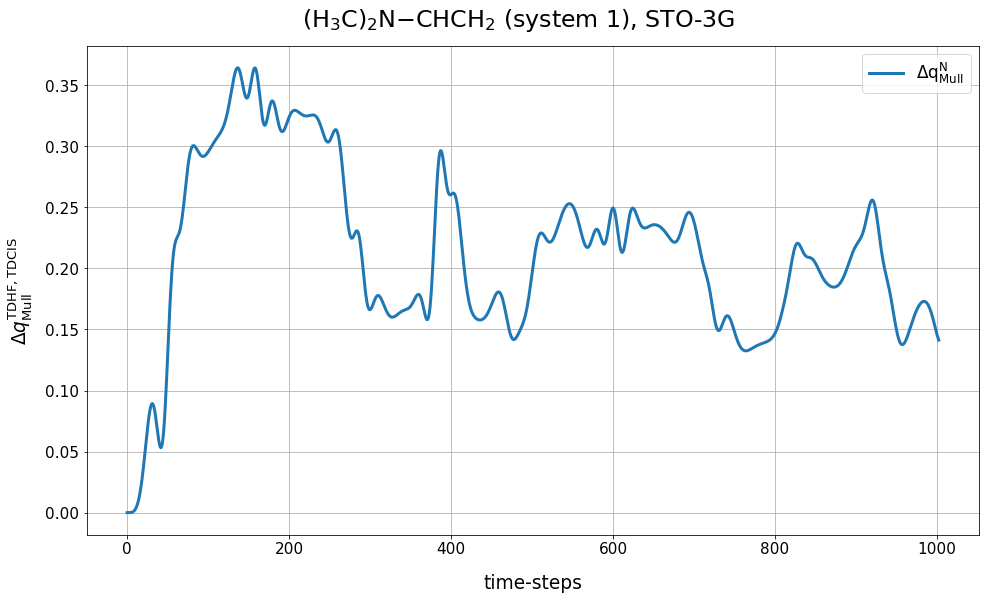

In [32]:
# '''
fig = plt.figure(figsize=(16,9))
l2s = 16/47.25
parameters = {'axes.labelsize': 45*l2s}
plt.rcParams.update(parameters)
plt.suptitle(r'$(\mathrm{H}_3\mathrm{C})_2\mathrm{N}\mathrm{-CHCH}_2$ (system 1), STO-3G', y=0.94, fontsize=70*l2s)
plt.xticks(fontsize=45*l2s)
plt.yticks(fontsize=45*l2s)
plt.xlabel('time-steps', fontdict={'size': 55*l2s}, labelpad=50*l2s)
plt.ylabel(r'$\Delta q_{\mathrm{Mull}}^{\mathrm{TDHF,TDCIS}}$', fontdict={'size': 55*l2s}, labelpad=30*l2s)
# Plot instantaneous dipole moment vs time-steps
x_i = range(tme)
plt.plot(x_i,(qMull_CI-qMull)[:len(x_i),2],linewidth=3,label=r'$\Delta \mathrm{q}_\mathrm{Mull}^\mathrm{N}$')
plt.grid(True)
plt.legend(loc='best',fontsize=50*l2s,ncol=3,).get_title().set_fontsize('{}'.format(55*l2s)) #,title=r'$\mathbf{Basis}$'
plt.show()
# '''

In [40]:
27.2114*(-0.16252+0.26014)

2.6563768679999997

In [42]:
np.array([-3.6702  ,   -0.9058 ,    -0.1437])/0.39343

array([-9.3287243 , -2.30231553, -0.36524922])